- ML MODEL METRIC (MSE R-squared) and R square Graph
- ML MODEL convergence data and curce

Ambil Data

In [1]:
import pandas as pd

# Definisi path
path_jw = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_jw/all/J-A-1/ml_training/train_data/train_data_1.csv"
path_bk = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_bk/all/BK-A-1/ml_training/train_data/train_data_1.csv"
path_parity = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_parity/all/P-A-1/ml_training/train_data/train_data_1.csv"

# Membaca masing-masing file
df_jw = pd.read_csv(path_jw)
df_bk = pd.read_csv(path_bk)
df_parity = pd.read_csv(path_parity)

# Menambahkan kolom label untuk membedakan sumber data
df_jw['experiment_type'] = 'jw'
df_bk['experiment_type'] = 'bk'
df_parity['experiment_type'] = 'parity'

# Menggabungkan ketiga DataFrame secara vertikal (baris)
df_combined = pd.concat([df_jw, df_bk, df_parity], ignore_index=True)
df_combined = df_combined.drop(columns='zne_energy', errors='ignore')

# Menampilkan informasi ringkas dari hasil penggabungan
print(df_combined.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   noisy_energy     6000 non-null   float64
 1   ideal_energy     6000 non-null   float64
 2   observable       6000 non-null   object 
 3   param_0          6000 non-null   float64
 4   param_1          6000 non-null   float64
 5   param_2          6000 non-null   float64
 6   param_3          6000 non-null   float64
 7   param_4          6000 non-null   float64
 8   param_5          6000 non-null   float64
 9   param_6          4000 non-null   float64
 10  param_7          4000 non-null   float64
 11  param_8          4000 non-null   float64
 12  param_9          4000 non-null   float64
 13  param_10         4000 non-null   float64
 14  param_11         4000 non-null   float64
 15  experiment_type  6000 non-null   object 
dtypes: float64(14), object(2)
memory usage: 750.1+ KB
None


Melakukan encoding untuk 4 qubits...
Encoding selesai. Dimensi DataFrame: (6000, 32)

==================== MEMULAI TRAINING ====================
Processing: Jordan-Wigner (jw)...
Processing: Bravyi-Kitaev (bk)...
Processing: Parity (parity)...


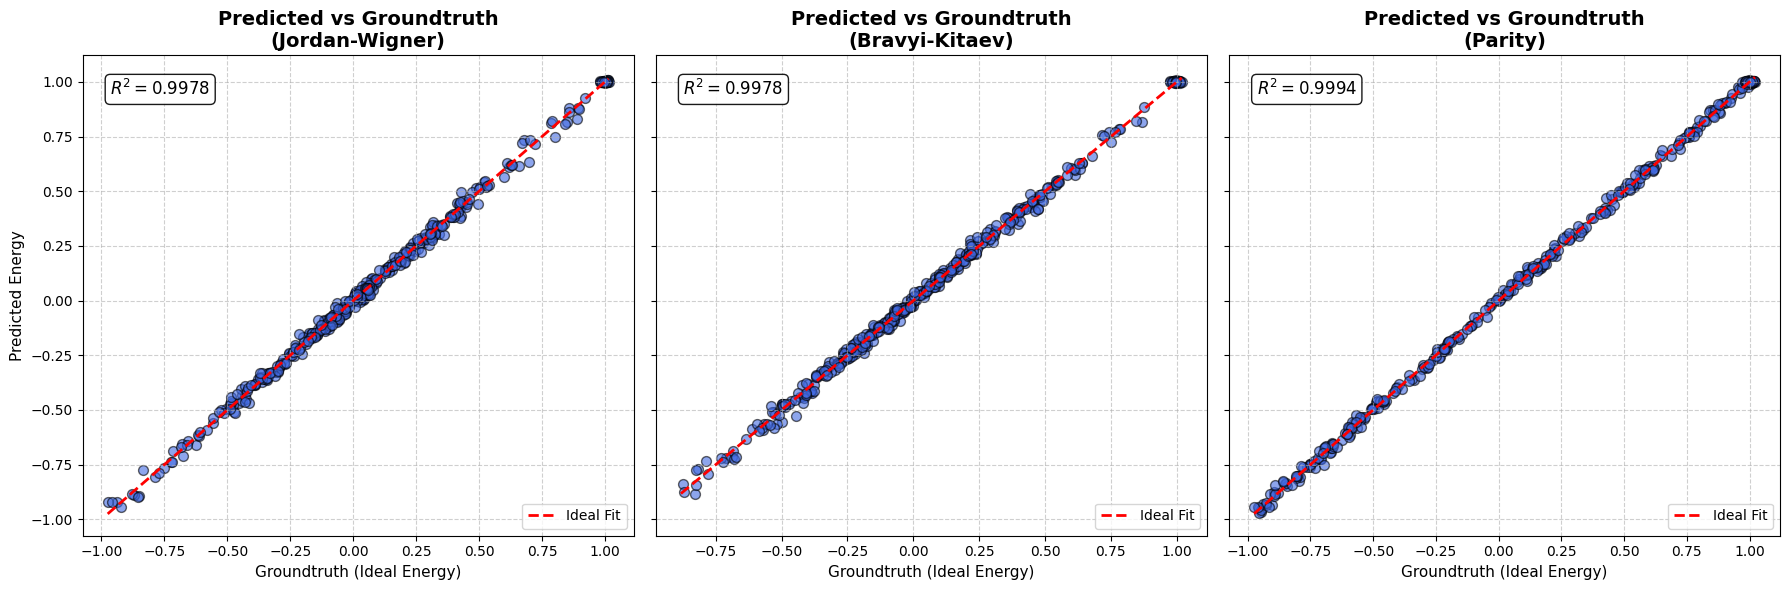

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# --- 0. KONFIGURASI NAMA (MAPPING SYSTEM) ---
# Di sini kita mendefinisikan perubahan nama singkatan -> nama lengkap
name_mapping = {
    'jw': 'Jordan-Wigner',
    'bk': 'Bravyi-Kitaev',
    'parity': 'Parity'
}

# --- 1. FEATURE ENGINEERING: OBSERVABLE ONE-HOT ENCODING ---
# Asumsi: df_combined sudah ada
n_qubits = len(df_combined['observable'].iloc[0])
print(f"Melakukan encoding untuk {n_qubits} qubits...")

for pos in range(n_qubits):
    for op in ["I", "X", "Y", "Z"]:
        col_name = f"obs{pos}{op}"
        if col_name not in df_combined.columns:
            df_combined[col_name] = (df_combined['observable'].str[pos] == op).astype(int)

print("Encoding selesai. Dimensi DataFrame:", df_combined.shape)

# --- 2. TRAINING & PLOTTING LOOP ---
experiment_types = ['jw', 'bk', 'parity']
metrics_list = [] 

# Siapkan canvas figure
fig, axes = plt.subplots(1, len(experiment_types), figsize=(18, 6), sharey=True)

print(f"\n{'='*20} MEMULAI TRAINING {'='*20}")

for i, exp_type in enumerate(experiment_types):
    # Ambil nama lengkap dari mapping, jika tidak ada pakai nama asli
    full_name = name_mapping.get(exp_type, exp_type) 
    
    print(f"Processing: {full_name} ({exp_type})...")
    
    # 1. Filter Data (Tetap pakai 'exp_type' yang asli sesuai isi data)
    df_exp = df_combined[df_combined['experiment_type'] == exp_type].copy()
    
    # 2. Definisi Fitur & Target
    drop_cols = ['ideal_energy', 'observable', 'experiment_type', 'zne_energy'] 
    X = df_exp.drop(columns=drop_cols, errors='ignore')
    y = df_exp['ideal_energy']
    
    # 3. Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # 4. Train Model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # 5. Prediksi
    y_pred = rf_model.predict(X_test)
    
    # 6. Hitung Metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Cross Validation
    cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
    
    # Simpan metrik (Gunakan 'full_name' agar tabel nanti rapi)
    metrics_list.append({
        'Transformation': full_name, # Kolom ini sekarang berisi nama lengkap
        'MSE': mse,
        'R2 Score': r2,
        'CV Mean R2': cv_scores.mean(),
        'CV Std R2': cv_scores.std()
    })
    
    # --- PLOTTING ---
    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolor='k', s=50)
    
    # Garis Ideal
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal Fit')
    
    # Judul & Label (Gunakan full_name)
    ax.set_title(f"Predicted vs Groundtruth\n({full_name})", fontsize=14, fontweight='bold')
    ax.set_xlabel("Groundtruth (Ideal Energy)", fontsize=11)
    
    if i == 0:
        ax.set_ylabel("Predicted Energy", fontsize=11)
        
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', frameon=True)
    
    # Teks R2
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, 
            fontsize=12, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

# --- 3. MENAMPILKAN TABEL HASIL ---
results_df = pd.DataFrame(metrics_list)

In [3]:
results_df

,Transformation,MSE,R2 Score,CV Mean R2,CV Std R2
0,Jordan-Wigner,0.000422,0.998057,0.997988,0.000161
1,Bravyi-Kitaev,0.000381,0.998264,0.998031,0.000152
2,Parity,0.000314,0.999280,0.999301,0.000031


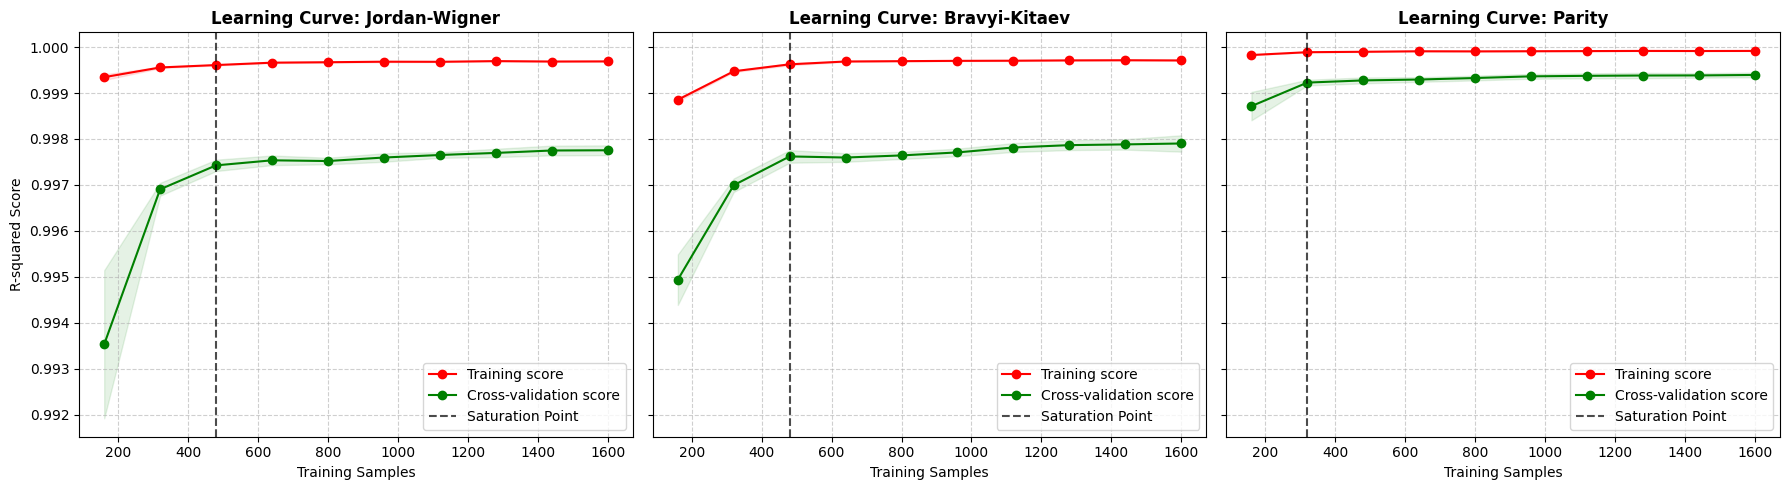

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestRegressor

# --- SETUP ---
experiment_types = ['jw', 'bk', 'parity']
cv_folds = 5 

# Mapping nama
name_mapping = {
    'jw': 'Jordan-Wigner',
    'bk': 'Bravyi-Kitaev',
    'parity': 'Parity'
}

# List untuk menampung hasil analisis
analysis_results = []

# --- MODIFIKASI: Inisialisasi subplot dengan sharey=True ---
# sharey=True membuat semua subplot menggunakan skala Y yang sama
# Ini otomatis menghilangkan label Y di plot ke-2 dan ke-3
fig, axes = plt.subplots(1, len(experiment_types), figsize=(18, 5), sharey=True)

for i, exp_type in enumerate(experiment_types):
    full_name = name_mapping.get(exp_type, exp_type)
    
    # 1. Persiapan Data
    df_exp = df_combined[df_combined['experiment_type'] == exp_type].copy()
    drop_cols = ['ideal_energy', 'observable', 'experiment_type', 'zne_energy']
    X = df_exp.drop(columns=drop_cols, errors='ignore')
    y = df_exp['ideal_energy']
    
    # 2. Hitung Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        RandomForestRegressor(n_estimators=100, random_state=42), 
        X, y, 
        cv=cv_folds, 
        scoring='r2', 
        n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 10)
    )

    # 3. Hitung Statistik
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # --- BARREN PLATEAU / SATURATION ANALYSIS ---
    delta_r2 = np.diff(test_mean)
    delta_n = np.diff(train_sizes)
    slopes = delta_r2 / delta_n

    epsilon = 1e-5  
    plateau_idx = None
    window = 2  

    for k in range(len(slopes) - window):
        if np.all(np.abs(slopes[k:k+window]) < epsilon):
            plateau_idx = k
            break

    saturation_point_str = "Not Detected"
    saturation_score = np.nan
    status_msg = "Still Improving"
    
    if plateau_idx is not None:
        plateau_size = train_sizes[plateau_idx + 1]
        plateau_score = test_mean[plateau_idx + 1]
        saturation_point_str = f"{plateau_size} Samples"
        saturation_score = plateau_score
        status_msg = "Saturated"
    else:
        plateau_size = None

    # --- ANALISIS KONVERGENSI ---
    max_score = np.max(test_mean)
    idx_converge = np.argmax(test_mean >= (max_score * 0.99))
    rows_needed = train_sizes[idx_converge]

    # Simpan Data
    analysis_results.append({
        'Transformation': full_name,
        'Max CV R2': max_score,
        'Full Data R2': test_mean[-1],
        'Convergence (99% Max)': f"{rows_needed} Samples",
        'Saturation Point': saturation_point_str,
        'Saturation R2': saturation_score if plateau_idx is not None else max_score,
        'Status': status_msg
    })

    # 4. Plotting (Gunakan axes[i])
    ax = axes[i] 
    
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
    ax.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

    ax.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
    ax.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
    
    if plateau_idx is not None:
        ax.axvline(plateau_size, color='k', linestyle='--', alpha=0.7, label="Saturation Point")
        
    ax.set_title(f"Learning Curve: {full_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Training Samples")
    
    # Hanya set Y Label untuk grafik pertama (paling kiri)
    if i == 0:
        ax.set_ylabel("R-squared Score")
        
    ax.legend(loc="best")
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# --- MENAMPILKAN DATAFRAME ---

df_analysis = pd.DataFrame(analysis_results)
pd.options.display.float_format = '{:,.4f}'.format
cols_order = ['Transformation', 'Status', 'Max CV R2', 'Full Data R2', 
              'Convergence (99% Max)', 'Saturation Point', 'Saturation R2']
df_analysis = df_analysis[cols_order]

In [4]:
df_analysis

,Transformation,Status,Max CV R2,Full Data R2,Convergence (99% Max),Saturation Point,Saturation R2
0,Jordan-Wigner,Saturated,0.9978,0.9978,160 Samples,480 Samples,0.9974
1,Bravyi-Kitaev,Saturated,0.9979,0.9979,160 Samples,480 Samples,0.9976
2,Parity,Saturated,0.9994,0.9994,160 Samples,320 Samples,0.9992


Ambil Data Predicted

In [5]:
import pandas as pd

# Definisi path
path_jw = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_jw/all/J-A-1/ml_training/predict_data/predicted_data_1.csv"
path_bk = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_bk/all/BK-A-1/ml_training/predict_data/predicted_data_1.csv"
path_parity = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_parity/all/P-A-1/ml_training/predict_data/predicted_data_1.csv"

# Membaca masing-masing file
df_jw = pd.read_csv(path_jw)
df_bk = pd.read_csv(path_bk)
df_parity = pd.read_csv(path_parity)

# Menambahkan kolom label untuk membedakan sumber data
df_jw['experiment_type'] = 'jw'
df_bk['experiment_type'] = 'bk'
df_parity['experiment_type'] = 'parity'

# Menggabungkan ketiga DataFrame secara vertikal (baris)
df_combined = pd.concat([df_jw, df_bk, df_parity], ignore_index=True)

# Menampilkan informasi ringkas dari hasil penggabungan
print(df_combined.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   noisy_energy     6000 non-null   float64
 1   ideal_energy     6000 non-null   float64
 2   zne_energy       6000 non-null   float64
 3   observable       6000 non-null   object 
 4   param_0          6000 non-null   float64
 5   param_1          6000 non-null   float64
 6   param_2          6000 non-null   float64
 7   param_3          6000 non-null   float64
 8   param_4          6000 non-null   float64
 9   param_5          6000 non-null   float64
 10  param_6          4000 non-null   float64
 11  param_7          4000 non-null   float64
 12  param_8          4000 non-null   float64
 13  param_9          4000 non-null   float64
 14  param_10         4000 non-null   float64
 15  param_11         4000 non-null   float64
 16  RF_energy        6000 non-null   float64
 17  experiment_typ

In [6]:


# Menghitung selisih mutlak (Absolute Error) untuk masing-masing metode
df_combined['AE_Noisy'] = (df_combined['noisy_energy'] - df_combined['ideal_energy']).abs()
df_combined['AE_ZNE'] = (df_combined['zne_energy'] - df_combined['ideal_energy']).abs()
df_combined['AE_RF'] = (df_combined['RF_energy'] - df_combined['ideal_energy']).abs()

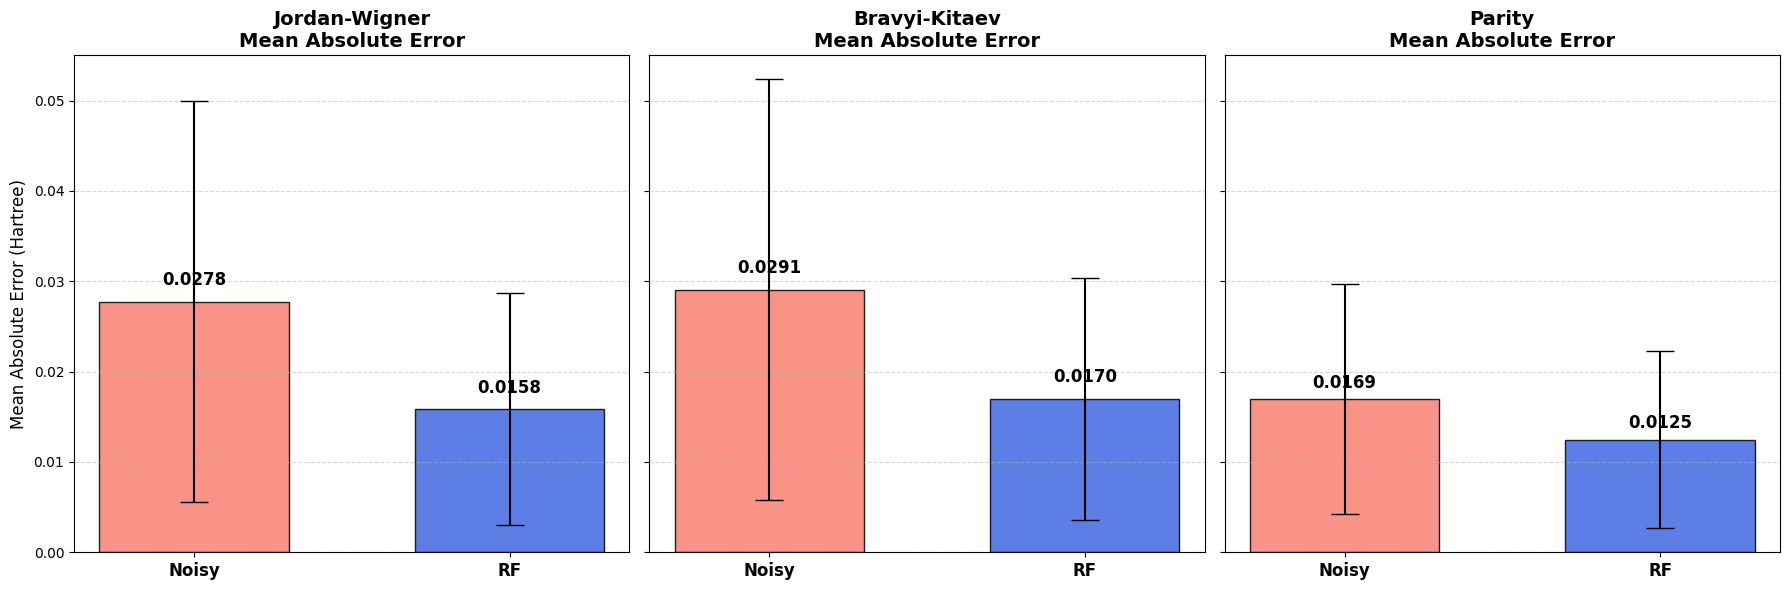

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- KONFIGURASI ---
experiment_types = ['jw', 'bk', 'parity']
name_mapping = {
    'jw': 'Jordan-Wigner',
    'bk': 'Bravyi-Kitaev',
    'parity': 'Parity'
}

# Kita hanya memplot Noisy dan RF, tapi akan menghitung ZNE untuk tabel
plot_methods = ['Noisy', 'RF']
plot_colors = ['salmon', 'royalblue']

# List untuk menampung data tabel
stats_list = []

# Siapkan Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, exp_type in enumerate(experiment_types):
    full_name = name_mapping.get(exp_type, exp_type)
    ax = axes[i]
    
    # 1. Ambil Data Subset
    subset = df_combined[df_combined['experiment_type'] == exp_type]
    
    # 2. Hitung Statistik (Mean & Std) untuk SEMUA metode (termasuk ZNE untuk tabel)
    m_noisy, s_noisy = subset['AE_Noisy'].mean(), subset['AE_Noisy'].std()
    m_zne, s_zne     = subset['AE_ZNE'].mean(), subset['AE_ZNE'].std()
    m_rf, s_rf       = subset['AE_RF'].mean(), subset['AE_RF'].std()
    
    # Simpan ke list untuk DataFrame nanti
    stats_list.append({
        'Transformation': full_name,
        'Noisy Mean': m_noisy, 'Noisy Std': s_noisy,
        'ZNE Mean': m_zne,     'ZNE Std': s_zne,     # ZNE tetap dicatat
        'RF Mean': m_rf,       'RF Std': s_rf
    })
    
    # 3. Siapkan Data KHUSUS PLOTTING (Hanya Noisy & RF)
    means_plot = [m_noisy, m_rf]
    stds_plot  = [s_noisy, s_rf]
    
    # 4. Plot Bar Chart
    bars = ax.bar(plot_methods, means_plot, yerr=stds_plot, align='center', 
                  color=plot_colors, alpha=0.85, edgecolor='black', capsize=10, width=0.6)
    
    # 5. Kosmetik Plot
    ax.set_title(f"{full_name}\nMean Absolute Error", fontsize=14, fontweight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    
    # Tambahkan Label Angka di atas Bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (0.05 * max(means_plot)), # Geser sedikit ke atas
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    # Label Sumbu
    if i == 0:
        ax.set_ylabel("Mean Absolute Error (Hartree)", fontsize=12)
    
    # Hapus tick x dan label metode di bawah agar bersih, atau biarkan ada
    ax.set_xticks(range(len(plot_methods)))
    ax.set_xticklabels(plot_methods, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


df_stats = pd.DataFrame(stats_list)

# Formatting agar tabel rapi
pd.options.display.float_format = '{:,.5f}'.format

# Mengatur urutan kolom agar mudah dibaca (Grouping per metode)
col_order = [
    'Transformation', 
    'Noisy Mean', 'Noisy Std', 
    'ZNE Mean', 'ZNE Std', 
    'RF Mean', 'RF Std'
]
df_stats = df_stats[col_order]

In [9]:
df_stats

,Transformation,Noisy Mean,Noisy Std,ZNE Mean,ZNE Std,RF Mean,RF Std
0,Jordan-Wigner,0.02776,0.02217,0.30496,0.25712,0.01878,0.01523
1,Bravyi-Kitaev,0.02907,0.02333,0.30861,0.25341,0.01954,0.01625
2,Parity,0.01693,0.01273,0.45794,0.48501,0.01336,0.01064


In [8]:
import pandas as pd

# Definisi path
path_jw = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_jw/all/J-A-1/vqe_execution/vqe_results_multi_bond_length.csv"
path_bk = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_bk/all/BK-A-1/vqe_execution/vqe_results_multi_bond_length.csv"
path_parity = "/home/fadhil/ml_qemV2/hasil_eksperimenV10_parity/all/P-A-1/vqe_execution/vqe_results_multi_bond_length.csv"

# Membaca masing-masing file
df_jw = pd.read_csv(path_jw)
df_bk = pd.read_csv(path_bk)
df_parity = pd.read_csv(path_parity)

# Menambahkan kolom label untuk membedakan sumber data
df_jw['experiment_type'] = 'jw'
df_bk['experiment_type'] = 'bk'
df_parity['experiment_type'] = 'parity'

# Menggabungkan ketiga DataFrame secara vertikal (baris)
df_combined = pd.concat([df_jw, df_bk, df_parity], ignore_index=True)

# Menampilkan informasi ringkas dari hasil penggabungan
print(df_combined.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   bond_length       24 non-null     float64
 1   ideal_energy      24 non-null     float64
 2   noisy_energy      24 non-null     float64
 3   zne_energy        24 non-null     float64
 4   mitigated_energy  24 non-null     float64
 5   status            24 non-null     object 
 6   error_msg         0 non-null      float64
 7   experiment_type   24 non-null     object 
dtypes: float64(6), object(2)
memory usage: 1.6+ KB
None


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan library qiskit-nature dan pyscf terinstall
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.units import DistanceUnit

# --- 1. FUNGSI NUCLEAR REPULSION ---
def nuclear_repulsion_h2(R):
    """
    Menghitung energi tolak-menolak antar inti atom (Nuclear Repulsion Energy)
    untuk molekul H2 pada jarak R (Angstrom).
    """
    try:
        driver = PySCFDriver(
            atom=f"H 0 0 0; H 0 0 {R}",
            basis="sto3g",
            charge=0,
            spin=0,
            unit=DistanceUnit.ANGSTROM,
        )
        problem = driver.run()
        return problem.nuclear_repulsion_energy
    except Exception as e:
        print(f"Error calculating repulsion for R={R}: {e}")
        return 0.0

# --- 2. PRE-CALCULATION (Agar Efisien) ---
# Kita buat dictionary mapping agar tidak menghitung ulang untuk jarak yang sama
unique_lengths = df_combined['bond_length'].unique()
repulsion_map = {}

for r in unique_lengths:
    # Membulatkan R agar key dictionary konsisten (opsional tapi disarankan)
    r_val = float(r) 
    repulsion_map[r_val] = nuclear_repulsion_h2(r_val)

# --- 3. MENAMBAHKAN ENERGI NUKLIR KE DATAFRAME ---
# Map nilai repulsion ke dataframe berdasarkan kolom bond_length
df_combined['nuc_repulsion'] = df_combined['bond_length'].map(repulsion_map)

# Buat kolom TOTAL Energy
df_combined['total_ideal_energy'] = df_combined['ideal_energy'] + df_combined['nuc_repulsion']
df_combined['total_mitigated_energy'] = df_combined['mitigated_energy'] + df_combined['nuc_repulsion']

# Jika ada kolom noisy_energy, tambahkan juga
if 'noisy_energy' in df_combined.columns:
    df_combined['total_noisy_energy'] = df_combined['noisy_energy'] + df_combined['nuc_repulsion']


<>:45: SyntaxWarning: invalid escape sequence '\A'
<>:45: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3108/3703876412.py:45: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel("Bond Length ($\AA$)", fontsize=14)


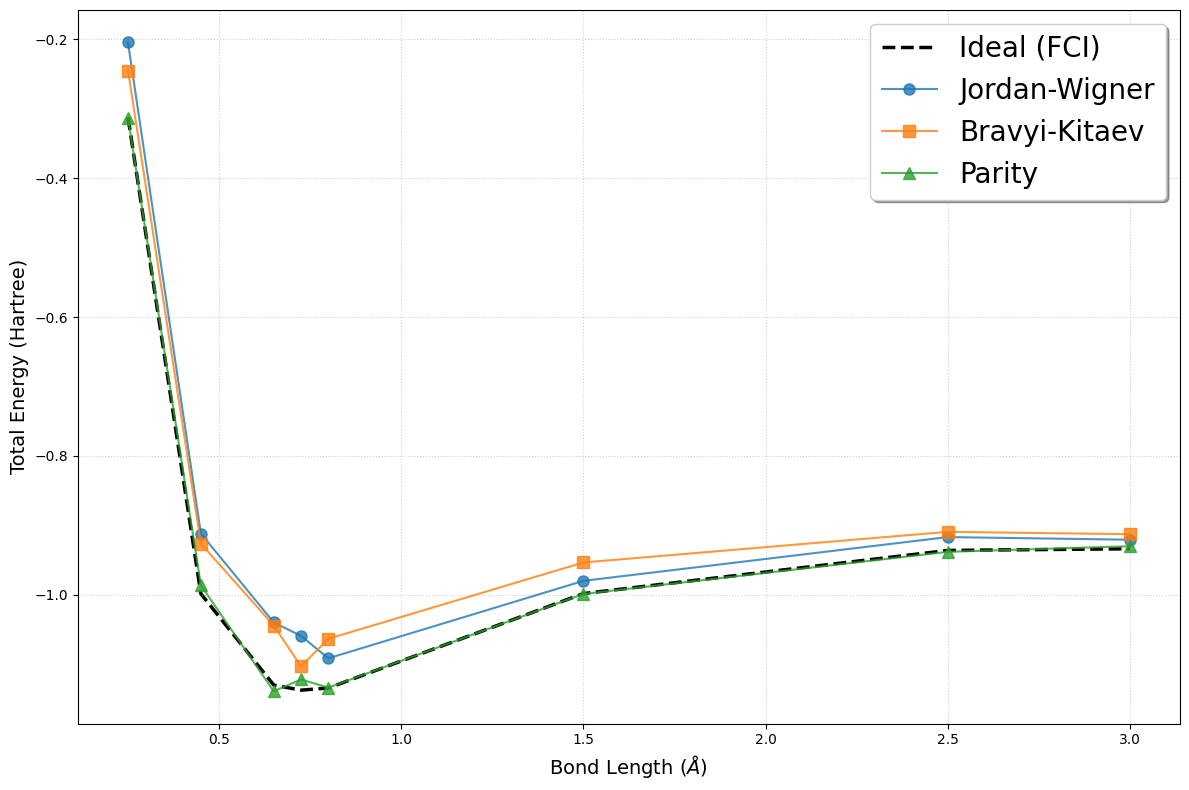

In [10]:
import matplotlib.pyplot as plt

# --- KONFIGURASI STYLE ---
# Dictionary untuk membedakan warna dan bentuk marker tiap eksperimen
plot_styles = {
    'jw':     {'color': '#1f77b4', 'marker': 'o', 'label': 'Jordan-Wigner'}, # Biru
    'bk':     {'color': '#ff7f0e', 'marker': 's', 'label': 'Bravyi-Kitaev'}, # Oranye
    'parity': {'color': '#2ca02c', 'marker': '^', 'label': 'Parity'}         # Hijau
}

plt.figure(figsize=(12, 8))

# --- 1. PLOT IDEAL ENERGY (REFERENCE) ---
# Ambil data dari salah satu tipe saja (misal JW) karena nilai Ideal-nya pasti sama
subset_ref = df_combined[df_combined['experiment_type'] == 'jw'].sort_values(by='bond_length')

plt.plot(subset_ref['bond_length'], subset_ref['total_ideal_energy'], 
         color='black', linestyle='--', linewidth=2.5, label='Ideal (FCI)', zorder=1)


# --- 2. PLOT MITIGATED ENERGY (PER EXPERIMENT) ---
experiment_types = ['jw', 'bk', 'parity']

for exp_type in experiment_types:
    # Filter dan urutkan data
    subset = df_combined[df_combined['experiment_type'] == exp_type].sort_values(by='bond_length')
    
    # Ambil style
    style = plot_styles[exp_type]
    
    # Plotting
    # alpha=0.7 agar agak transparan sedikit jika ada yang menumpuk total
    plt.plot(subset['bond_length'], subset['total_mitigated_energy'],
             color=style['color'], 
             marker=style['marker'], 
             markersize=8, 
             linestyle='-', 
             linewidth=1.5,
             alpha=0.8,
             label=style['label'],
             zorder=2)

# --- 3. KOSMETIK GRAFIK ---
# plt.title("Comparison of H2 Dissociation Curves\n(Different Qubit Mappings)", fontsize=16, fontweight='bold')
plt.xlabel("Bond Length ($\AA$)", fontsize=14)
plt.ylabel("Total Energy (Hartree)", fontsize=14)
plt.grid(True, which='both', linestyle=':', alpha=0.6)

# Mengatur Legend
plt.legend(fontsize=20,loc='upper right', frameon=True, shadow=True)

# (Opsional) Zoom ke area equilibrium agar perbedaan terlihat jelas
# Biasanya equilibrium H2 ada di sekitar -1.137 Hartree
# plt.ylim(-1.15, -1.0) 

plt.tight_layout()
plt.show()

<>:51: SyntaxWarning: invalid escape sequence '\A'
<>:51: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_3108/1741601538.py:51: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel("Bond Length ($\AA$)", fontsize=12)


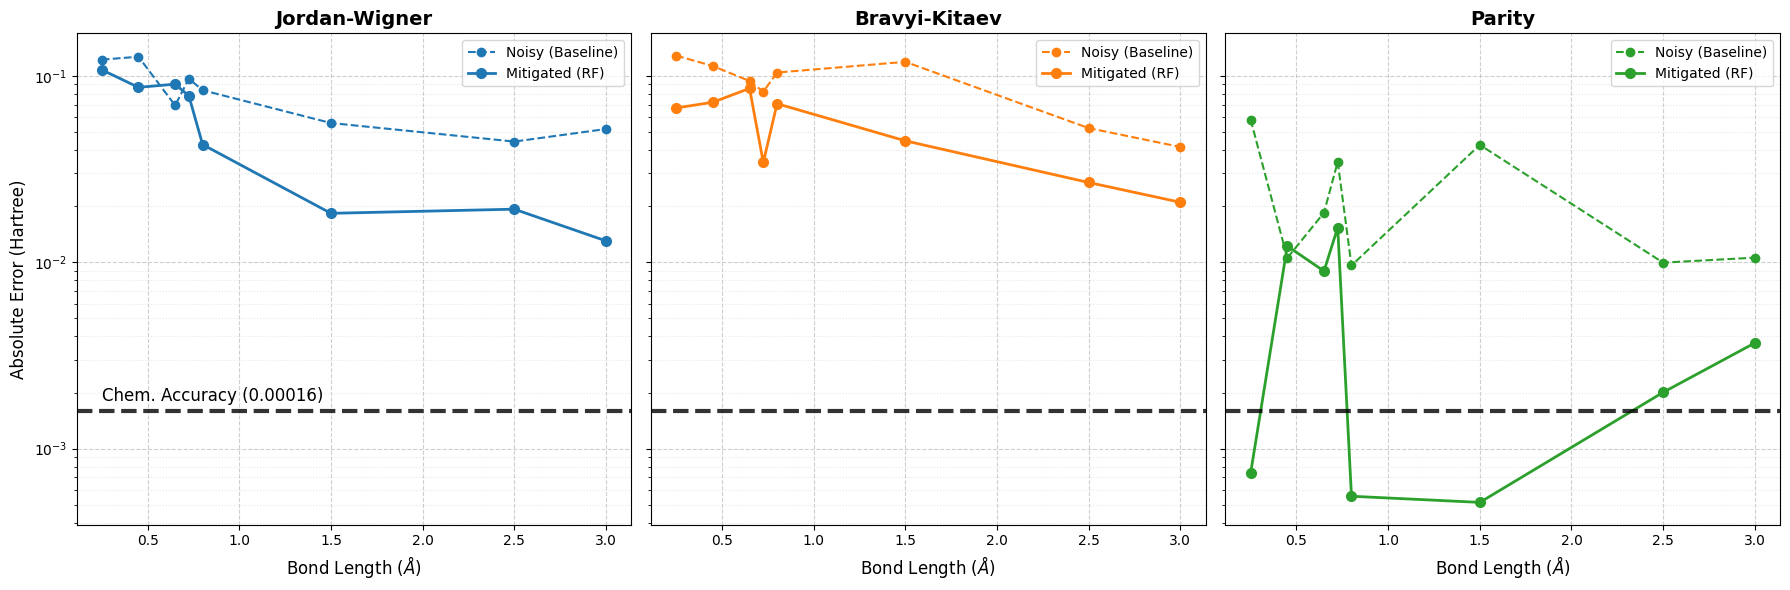

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. SETUP DATA (Sama seperti sebelumnya) ---
col_ideal = 'total_ideal_energy' if 'total_ideal_energy' in df_combined.columns else 'ideal_energy'
col_noisy = 'total_noisy_energy' if 'total_noisy_energy' in df_combined.columns else 'noisy_energy'
col_mitigated = 'total_mitigated_energy' if 'total_mitigated_energy' in df_combined.columns else 'mitigated_energy'

df_combined['abs_err_noisy'] = (df_combined[col_noisy] - df_combined[col_ideal]).abs()
df_combined['abs_err_mitigated'] = (df_combined[col_mitigated] - df_combined[col_ideal]).abs()

# --- 2. KONFIGURASI VISUAL ---
# Format Warna: {Kunci: {'main': WarnaTua, 'light': WarnaMuda, 'label': Judul}}
style_map = {
    'jw':     {'main': '#1f77b4', 'light': "#E3A6A6", 'label': 'Jordan-Wigner'}, 
    'bk':     {'main': '#ff7f0e', 'light': '#FDBF6F', 'label': 'Bravyi-Kitaev'}, 
    'parity': {'main': '#2ca02c', 'light': '#B2DF8A', 'label': 'Parity'}        
}
experiment_types = ['jw', 'bk', 'parity']

# --- 3. PLOTTING SIDE-BY-SIDE ---
# sharey=True agar skala Y sama untuk ketiga grafik (mudah dibandingkan)
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

for i, exp_type in enumerate(experiment_types):
    ax = axes[i]
    style = style_map[exp_type]
    
    # Filter & Sort Data (Penting: Sort by bond_length agar garis nyambung)
    subset = df_combined[df_combined['experiment_type'] == exp_type].sort_values(by='bond_length')
    X_data = subset['bond_length']

    # --- PLOT NOISY (Warna Muda + Putus-putus) ---
    ax.plot(X_data, subset['abs_err_noisy'], 
            color=style['main'], 
            marker='o', markersize=6, 
            linestyle='--', linewidth=1.5,
            label='Noisy (Baseline)')

    # --- PLOT MITIGATED (Warna Tua + Garis Tegas) ---
    ax.plot(X_data, subset['abs_err_mitigated'], 
            color=style['main'], 
            marker='o', markersize=7, 
            linestyle='-', linewidth=2,
            label='Mitigated (RF)')

    # --- KOSMETIK SUBPLOT ---
    ax.set_yscale('log') # Skala Log
    ax.set_title(style['label'], fontsize=14, fontweight='bold')
    ax.set_xlabel("Bond Length ($\AA$)", fontsize=12)
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.grid(True, which='minor', linestyle=':', alpha=0.3)
    
    # Garis Chemical Accuracy (Opsional: 1.6 mHa)
    ax.axhline(y=0.0016, color='black', linestyle='--', linewidth=3, alpha=0.8)
    
    # Label Y hanya di grafik paling kiri
    if i == 0:
        ax.set_ylabel("Absolute Error (Hartree)", fontsize=12)
        ax.text(X_data.min(), 0.0018, 'Chem. Accuracy (0.00016)', fontsize=12, color='black')
    
    # Legend di tiap plot
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# --- KONFIGURASI NAMA ---
name_mapping = {
    'jw': 'Jordan-Wigner',
    'bk': 'Bravyi-Kitaev',
    'parity': 'Parity'
}

# --- 1. MENGHITUNG RATA-RATA (MEAN) ---
# Mengelompokkan berdasarkan tipe eksperimen dan mencari rata-rata dari kolom error
df_summary = df_combined.groupby('experiment_type')[['abs_err_noisy', 'abs_err_mitigated']].mean().reset_index()

# --- 2. FORMATTING TABEL ---
# Mengganti singkatan menjadi nama lengkap
df_summary['experiment_type'] = df_summary['experiment_type'].map(name_mapping)

# Menghitung Persentase Perbaikan (Improvement)
# Rumus: (Noisy - Mitigated) / Noisy * 100
df_summary['Improvement (%)'] = (
    (df_summary['abs_err_noisy'] - df_summary['abs_err_mitigated']) / 
    df_summary['abs_err_noisy']
) * 100

# Mengganti nama kolom agar lebih profesional (disertai satuan Hartree)
df_summary.columns = [
    'Transformation', 
    'Mean Noisy Error (Ha)', 
    'Mean Mitigated Error (Ha)', 
    'Improvement (%)'
]

# Mengatur urutan kolom (opsional)
df_summary = df_summary[['Transformation', 'Mean Noisy Error (Ha)', 'Mean Mitigated Error (Ha)', 'Improvement (%)']]

# --- 3. MENAMPILKAN HASIL ---
print("\n" + "="*20 + " SUMMARY: AVERAGE ERROR COMPARISON " + "="*20)

# Format angka desimal agar rapi (5 angka di belakang koma)
pd.options.display.float_format = '{:,.4f}'.format

df_summary


==================== SUMMARY: AVERAGE ERROR COMPARISON ====================


,Transformation,Mean Noisy Error (Ha),Mean Mitigated Error (Ha),Improvement (%)
0,Bravyi-Kitaev,0.0918,0.0528,42.4151
1,Jordan-Wigner,0.0813,0.0570,29.8756
2,Parity,0.0243,0.0055,77.3675
